**Customer Churn Analysis — Exploratory Data Analysis**

**1. Importing dependencies**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**2. Data Loading and Understanding**

In [7]:
# load the csv data to a pandas dataframe
df=pd.read_csv("/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.shape

(7043, 21)

In [8]:
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**3. Data Cleaning**

In [ ]:
# Fix TotalCharges — 11 blank rows (new customers with 0 tenure)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Missing TotalCharges: {df["TotalCharges"].isna().sum()}')
df['TotalCharges'].fillna(0, inplace=True)

# Encode target
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

print('\nChurn distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {df["Churn_Binary"].mean()*100:.1f}%')

Missing TotalCharges: 11

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


**4. Churn Distribution**

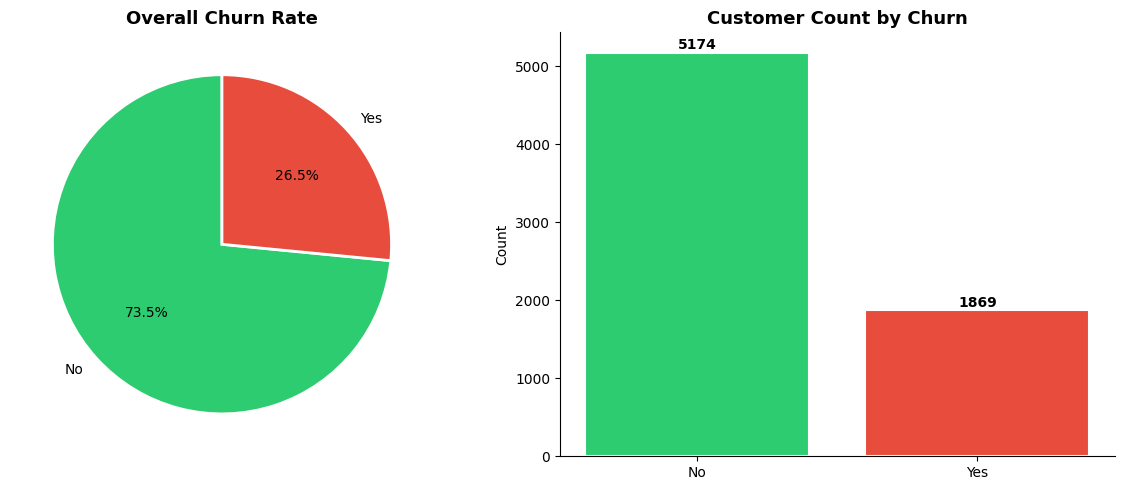

Class imbalance ratio (No:Yes): 2.77


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
counts = df['Churn'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Overall Churn Rate', fontsize=13, fontweight='bold')

# Count bar
colors = ['#2ecc71' if x == 'No' else '#e74c3c' for x in counts.index]
bars = axes[1].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 str(val), ha='center', fontweight='bold')
axes[1].set_title('Customer Count by Churn', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print('Class imbalance ratio (No:Yes):', round(counts['No']/counts['Yes'], 2))

**5. Numerical Features vs Churn**

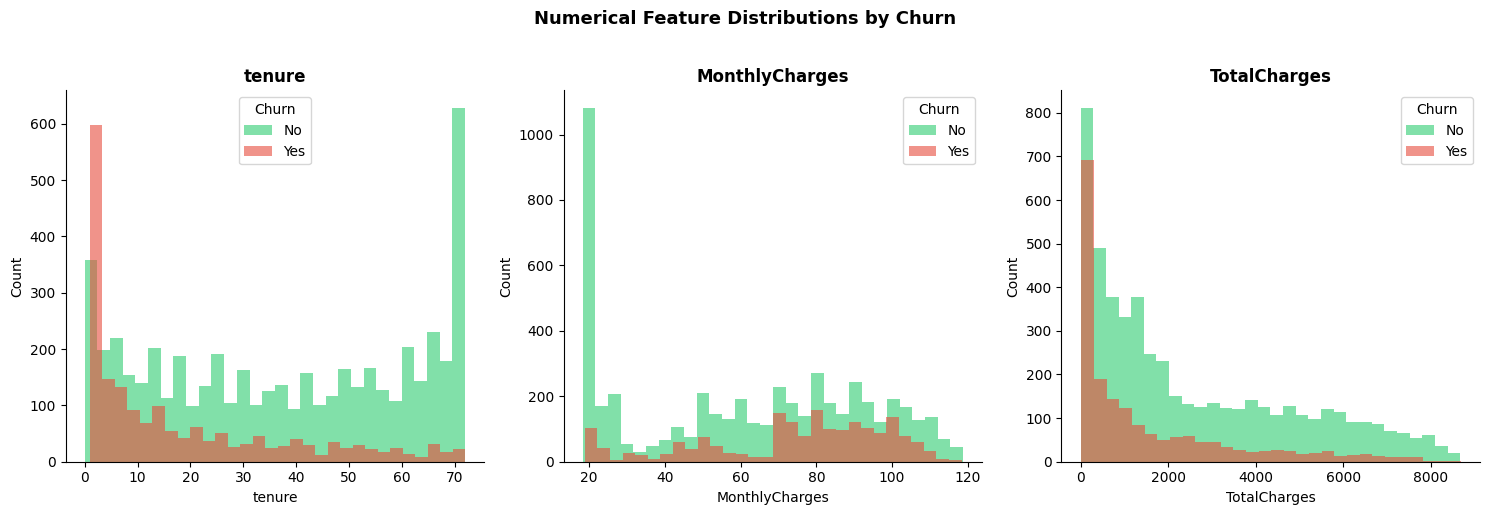

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80


In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, num_cols):
    for label, color in [('No','#2ecc71'), ('Yes','#e74c3c')]:
        ax.hist(df[df['Churn']==label][col], bins=30, alpha=0.6,
                color=color, label=label, edgecolor='none')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(title='Churn')

plt.suptitle('Numerical Feature Distributions by Churn', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
print(df.groupby('Churn')[num_cols].mean().round(2))

**6. Categorical Features vs Churn**

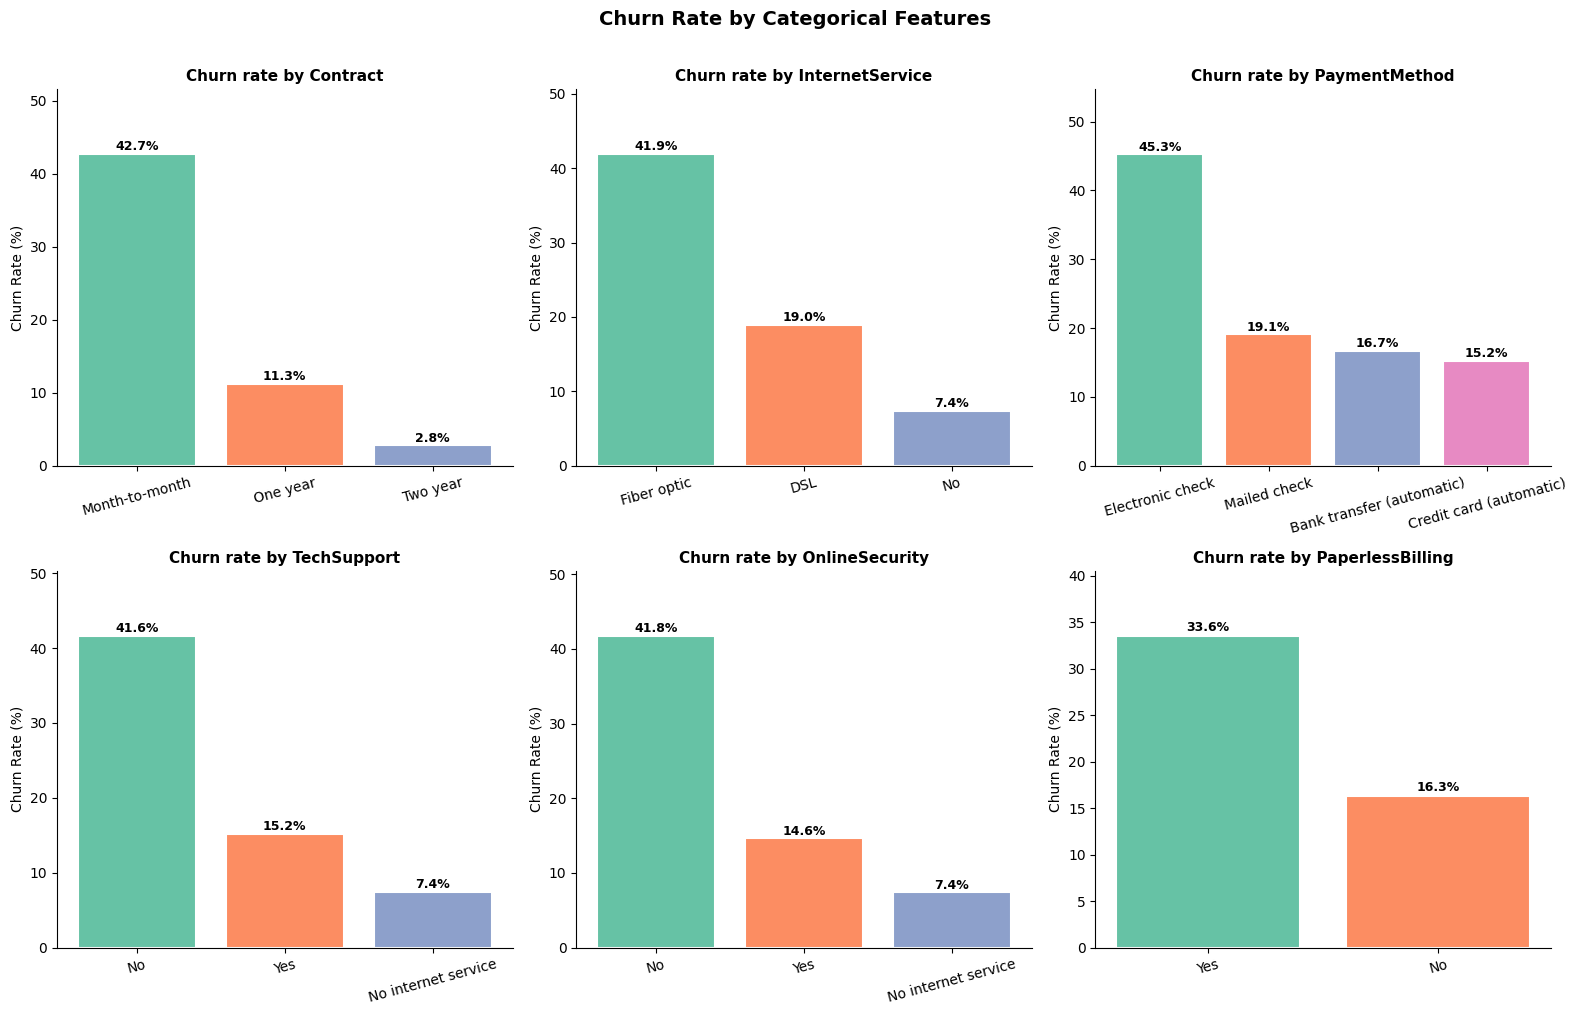

In [ ]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn_Binary'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values * 100,
                  color=sns.color_palette('Set2', len(churn_rate)),
                  edgecolor='white', linewidth=1.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Churn rate by {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**7. Tenure & Contract Type Deep Dive**

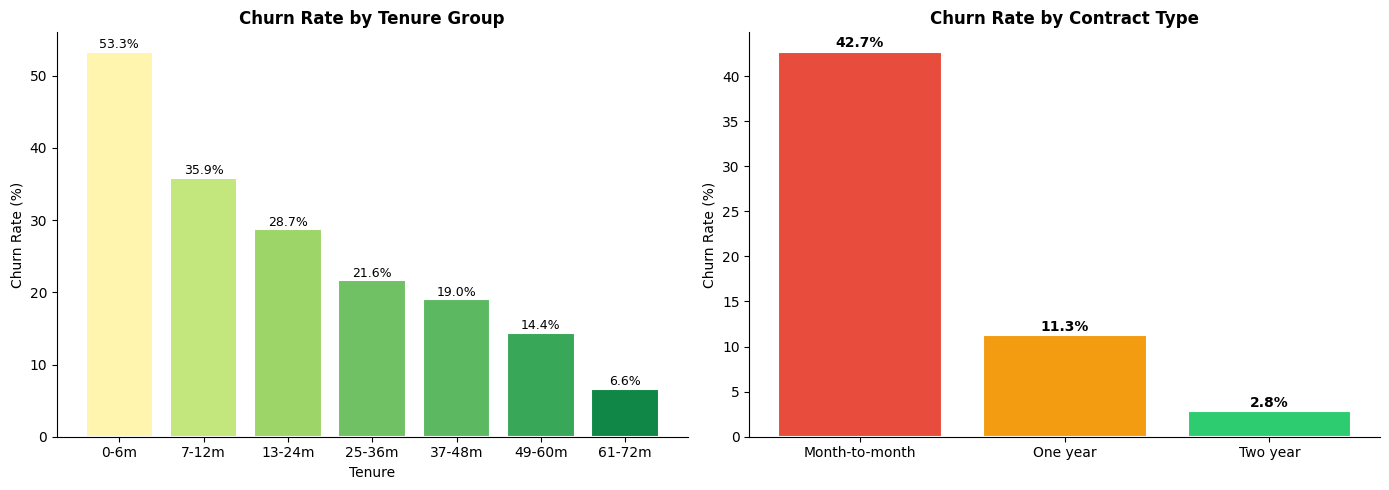

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure bins
df['tenure_group'] = pd.cut(df['tenure'],
    bins=[0, 6, 12, 24, 36, 48, 60, 72],
    labels=['0-6m','7-12m','13-24m','25-36m','37-48m','49-60m','61-72m'])
churn_by_tenure = df.groupby('tenure_group', observed=True)['Churn_Binary'].mean() * 100
axes[0].bar(churn_by_tenure.index, churn_by_tenure.values,
            color=plt.cm.RdYlGn_r(churn_by_tenure.values/100),
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Rate by Tenure Group', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Tenure')
for i, v in enumerate(churn_by_tenure.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# Contract type
contract_churn = df.groupby('Contract')['Churn_Binary'].mean().sort_values(ascending=False) * 100
colors = ['#e74c3c','#f39c12','#2ecc71']
bars = axes[1].bar(contract_churn.index, contract_churn.values, color=colors,
                   edgecolor='white', linewidth=1.5)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

**8. Correlation Heatmap**

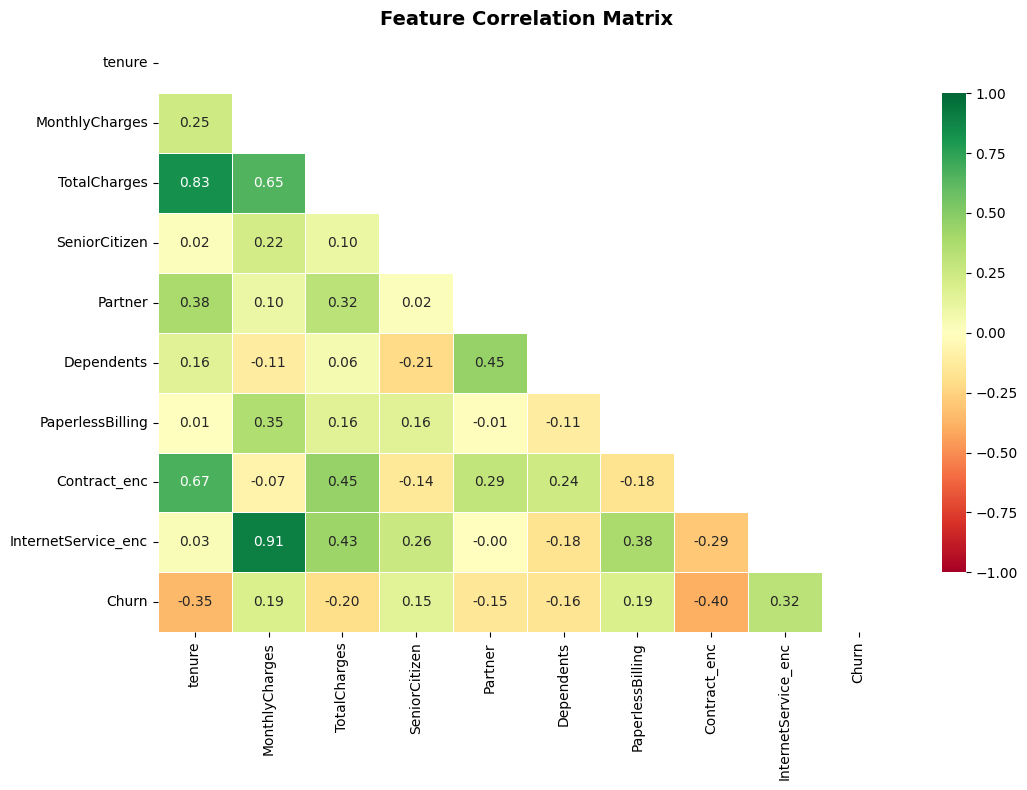


Top correlations with Churn:
Contract_enc          -0.397
tenure                -0.352
TotalCharges          -0.198
Dependents            -0.164
Partner               -0.150
SeniorCitizen          0.151
PaperlessBilling       0.192
MonthlyCharges         0.193
InternetService_enc    0.317
Name: Churn, dtype: float64


In [ ]:
# Encode all categoricals for correlation
df_enc = df.copy()
yes_no_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in yes_no_cols:
    df_enc[col] = (df_enc[col] == 'Yes').astype(int)

df_enc['gender'] = (df_enc['gender'] == 'Male').astype(int)
df_enc['Contract_enc'] = df_enc['Contract'].map(
    {'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df_enc['InternetService_enc'] = df_enc['InternetService'].map(
    {'No': 0, 'DSL': 1, 'Fiber optic': 2})

corr_cols = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen',
             'Partner','Dependents','PaperlessBilling',
             'Contract_enc','InternetService_enc','Churn']

corr = df_enc[corr_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop correlations with Churn:')
print(corr['Churn'].drop('Churn').sort_values().round(3))

**9. Monthly Charges vs Tenure (scatter)**

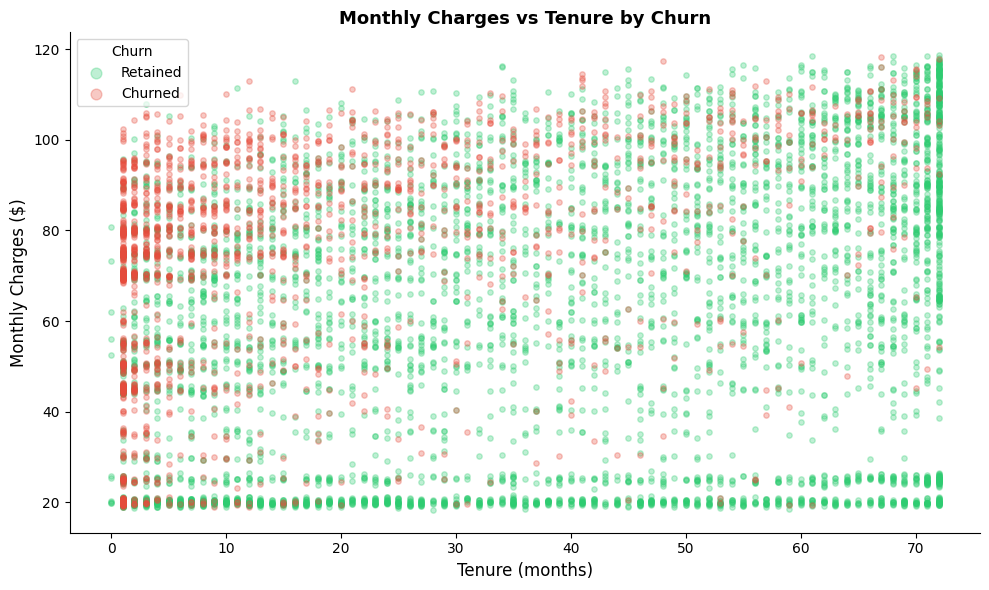

Key insight: High charges + low tenure = highest churn risk


In [ ]:
plt.figure(figsize=(10, 6))
for churn_val, color, label in [('No','#2ecc71','Retained'), ('Yes','#e74c3c','Churned')]:
    sub = df[df['Churn'] == churn_val]
    plt.scatter(sub['tenure'], sub['MonthlyCharges'],
                alpha=0.3, s=15, color=color, label=label)

plt.xlabel('Tenure (months)', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
plt.title('Monthly Charges vs Tenure by Churn', fontsize=13, fontweight='bold')
plt.legend(title='Churn', markerscale=2)
plt.tight_layout()
plt.show()
print('Key insight: High charges + low tenure = highest churn risk')

**10. EDA Summary**

In [ ]:
print('='*55)
print('          EDA KEY FINDINGS')
print('='*55)
churn_rate = df['Churn_Binary'].mean()*100
print(f'Overall churn rate        : {churn_rate:.1f}%')
mtm = df[df['Contract']=='Month-to-month']['Churn_Binary'].mean()*100
fiber = df[df['InternetService']=='Fiber optic']['Churn_Binary'].mean()*100
no_sec = df[df['OnlineSecurity']=='No']['Churn_Binary'].mean()*100
early = df[df['tenure']<=6]['Churn_Binary'].mean()*100
print(f'Month-to-month contract   : {mtm:.1f}% churn (highest risk)')
print(f'Fiber optic internet      : {fiber:.1f}% churn')
print(f'No online security        : {no_sec:.1f}% churn')
print(f'Tenure <= 6 months        : {early:.1f}% churn')
avg_mc_churn = df[df['Churn']=='Yes']['MonthlyCharges'].mean()
avg_mc_no = df[df['Churn']=='No']['MonthlyCharges'].mean()
print(f'Avg monthly charges (churn): ${avg_mc_churn:.2f}')
print(f'Avg monthly charges (kept) : ${avg_mc_no:.2f}')
print('='*55)

          EDA KEY FINDINGS
Overall churn rate        : 26.5%
Month-to-month contract   : 42.7% churn (highest risk)
Fiber optic internet      : 41.9% churn
No online security        : 41.8% churn
Tenure <= 6 months        : 52.9% churn
Avg monthly charges (churn): $74.44
Avg monthly charges (kept) : $61.27


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
